# HVSR 2023-05-20 15:44 (hora de Colombia)

**Lugar (bitácora de campo):** Terraza 73, base muro barrigón.

Sesión `CBUCF_titanSMA_1614_20230520_204400_01`, inicio 2023-05-20 20:44 UTC. Es una de las sesiones con A0≥2 en el cribado de [hvsr_analysis_other_sessions.ipynb](hvsr_analysis_other_sessions.ipynb). Se usa el perfil con A0≥2 mejor ordenado por claridad, fiabilidad, estabilidad entre bloques y A0 (el mismo criterio que reproduce el perfil de [hvsr_analysis_2023-05-19_1748.ipynb](hvsr_analysis_2023-05-19_1748.ipynb)).

**Resultado (banda 1–100 Hz):** f0≈92.04 Hz, A0≈4.41, 64 ventanas; fiabilidad 3/3, claridad 4/6 (falla C2, C5); desviación máxima del pico entre bloques ≈5.3%. En el cribado limitado a 1–50 Hz el pico era f0≈1.14 Hz, A0≈2.43. Al ampliar la banda, el máximo se desplaza a 92 Hz, por encima del límite del cribado y muy cerca de Nyquist, donde el espectro de Fourier cae por el filtro anti-alias; es probable que sea un artefacto. La banda SESAME f0/4–4·f0 (23.01–368.2 Hz) no queda dentro de la búsqueda 1–100 Hz (4·f0 supera Nyquist (100 Hz)), por lo que la cobertura es incompleta. **No se etiqueta como pico defendible**; candidato exploratorio de una sesión, con sitio físico, orientación y unidades no verificados.


In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next((folder for folder in (WORKING_DIR, *WORKING_DIR.parents)
             if (folder / 'utils/hvsr_tools.py').is_file() and (folder / 'data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Ejecuta desde la raíz del repositorio o desde main/02_processing.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv
from utils import plotting as hp

SESSION_ID = 'CBUCF_titanSMA_1614_20230520_204400_01'
manifest_path = ROOT / 'data/accelerometer/2023-05-20/sessions.json'
manifest = json.loads(manifest_path.read_text())
matches = [item for item in manifest['sessions'] if item['session_id'] == SESSION_ID]
if len(matches) != 1:
    raise ValueError(f'Se esperaba exactamente una sesión catalogada: {SESSION_ID}')
session = matches[0]
if session['loader_status'] != 'verified' or session['source_kind'] != 'individual_export':
    raise ValueError('La sesión no es una exportación individual verificada.')
INPUT_FILES = [ROOT / path for path in session['input_files']]
record = hv.load_record(INPUT_FILES, starttime=session['starttime'], endtime=session['endtime'])
record.meta.update(session_id=SESSION_ID, site_label=session.get('physical_site', 'unknown'),
                   site_label_source='catalog; field site and sensor orientation unverified')
display(pd.Series({
    'session_id': SESSION_ID,
    'start_utc': session['starttime'],
    'end_utc': session['endtime'],
    'duration_min': record.meta['duration_s'] / 60,
    'sampling_rate_hz': record.meta['sampling_rate_hz'],
    'nyquist_hz': 0.5 * record.meta['sampling_rate_hz'],
    'physical_site': session.get('physical_site', 'unknown'),
    'orientation_and_units': session.get('orientation_and_units', 'not verified'),
}, name='Registro analizado'))

session_id               CBUCF_titanSMA_1614_20230520_204400_01
start_utc                           2023-05-20T20:44:00.000000Z
end_utc                             2023-05-20T21:06:39.165000Z
duration_min                                           22.65275
sampling_rate_hz                                          200.0
nyquist_hz                                                100.0
physical_site                                           unknown
orientation_and_units                              not_verified
Name: Registro analizado, dtype: object

## Parámetros seleccionados

Perfil del barrido: ventanas de 15 s sin solapamiento, anti-trigger desactivado, crest factor máximo 15.0, detrend constant, Konno-Ohmachi B=20, combinación squared_average, rechazo frecuencial activado. Como en el notebook de referencia, el espectro se amplía hasta Nyquist (100 Hz) y la búsqueda del pico a 1–100 Hz; no se usa zero-padding.

In [2]:
params = hv.HVSRParams(
    window_length_s=15.0,
    overlap_pct=0.0,
    window_selection='continuous',
    anti_trigger=False,
    sta_s=2.0,
    lta_s=30.0,
    sta_lta_min=0.1,
    sta_lta_max=3.0,
    sta_lta_method='vector',
    sta_lta_amplitude='abs',
    transient_padding_s=2.0,
    max_crest_factor=15.0,
    filter_corners_hz=(None, None),
    detrend='constant',
    taper_pct_per_side=5.0,
    fft_zero_padding=False,
    smoothing='konno_and_ohmachi',
    smoothing_bandwidth=20.0,
    horizontal_combination='squared_average',
    fmin=0.2,
    fmax=100.0,
    n_frequencies=1200,
    frequency_spacing='log',
    peak_range_hz=(1.0, 100.0),
    frequency_domain_rejection=True,
    fdr_n=2.5,
)
result = hv.run_hvsr(record, params)
quality = hv.assess_sesame_quality(result, time_blocks=4)
coverage = hv.accepted_signal_coverage(result)
display(pd.Series(result.summary(), name='Resumen HVSR'))
display(pd.DataFrame(quality['criteria']))
display(pd.Series(quality['metrics'], name='Métricas de calidad'))
display(pd.DataFrame(quality['time_blocks']))
print(f"f0={result.peak[0]:.3f} Hz; A0={result.peak[1]:.3f}; "
      f"claridad={quality['metrics']['clarity_count']}/6; "
      f"fiabilidad={quality['metrics']['reliability_count']}/3")
print(f"Nyquist={0.5 / record.vt.dt_in_seconds:.3f} Hz; "
      f"4*f0={4 * result.peak[0]:.3f} Hz; "
      f"cobertura SESAME completa={quality['metrics']['frequency_coverage_complete']}")
if not quality['metrics']['frequency_coverage_complete']:
    warnings.warn('La banda registrada no llega hasta 4*f0; no afirmar validación SESAME completa.', RuntimeWarning)

64/90 windows | f0=92.04151 Hz | A0=4.41133


n_grid_windows                90.000000
n_windows_time_selection      64.000000
n_candidates_before_crest     90.000000
n_crest_rejected              26.000000
n_windows                     64.000000
retained_fraction              0.711111
f0_mean_curve_hz              92.041507
A0_mean_curve                  4.411332
f0_windows_hz                 34.602236
f0_windows_low_hz              5.716762
f0_windows_high_hz           209.439302
f0_windows_std_hz             38.373341
A0_windows                     4.280260
fdr_iterations                 1.000000
runtime_s                      0.178000
Name: Resumen HVSR, dtype: float64

,criterion,description,value,comparison,threshold,passed
0,R1,Cycles per window,1380.622602,>,10.00,True
1,R2,Total cycles,88359.846502,>,200.00,True
2,R3,"Maximum amplitude scatter in [f0/2, 2*f0]",1.309937,<,2.00,True
3,C1,Minimum amplitude below peak / A0,0.145218,<,0.50,True
4,C2,Minimum amplitude above peak / A0,0.972110,<,0.50,False
5,C3,Peak amplitude,4.411332,>,2.00,True
6,C4,Maximum relative shift of +/-1 sigma peaks,0.015671,<,0.05,True
7,C5,Window-peak standard deviation / f0,0.416913,<,0.05,False
8,C6,Amplitude scatter at f0,1.293986,<,1.58,True


reliability_count                          3
clarity_count                              4
sesame_passed                          False
retained_fraction                   0.711111
frequency_coverage_complete            False
fn_std_hz                          38.373341
sigma_a_at_peak                     1.293986
R1                                      True
R2                                      True
R3                                      True
C1                                      True
C2                                     False
C3                                      True
C4                                      True
C5                                     False
C6                                      True
time_blocks_complete                    True
block_global_max_deviation_pct      5.319836
block_tracked_max_deviation_pct     5.319836
Name: Métricas de calidad, dtype: object

,block,start_s,end_s,n_windows,f0_global_hz,A0_global,f0_tracked_hz,A0_tracked
0,1,0.00000,339.79125,12,89.223163,3.567262,89.223163,3.567262
1,2,339.79125,679.58250,21,90.621379,4.738529,90.621379,4.738529
2,3,679.58250,1019.37375,19,92.041507,4.353890,92.041507,4.353890
3,4,1019.37375,1359.16500,12,96.937964,5.001928,96.937964,5.001928


f0=92.042 Hz; A0=4.411; claridad=4/6; fiabilidad=3/3
Nyquist=100.000 Hz; 4*f0=368.166 Hz; cobertura SESAME completa=False


/tmp/ipykernel_131018/964080567.py:43: RuntimeWarning: La banda registrada no llega hasta 4*f0; no afirmar validación SESAME completa.
  warnings.warn('La banda registrada no llega hasta 4*f0; no afirmar validación SESAME completa.', RuntimeWarning)


## Figura del análisis

Panel izquierdo: curvas HVSR de ventanas aceptadas, media y dispersión lognormal. Panel derecho: medias HVSR por bloque cronológico y sus picos. La línea A0=2 es una referencia visual, no un criterio suficiente de defendibilidad.

/tmp/ipykernel_131018/1308312897.py:16: UserWarning: The figure layout has changed to tight
  figure.tight_layout()


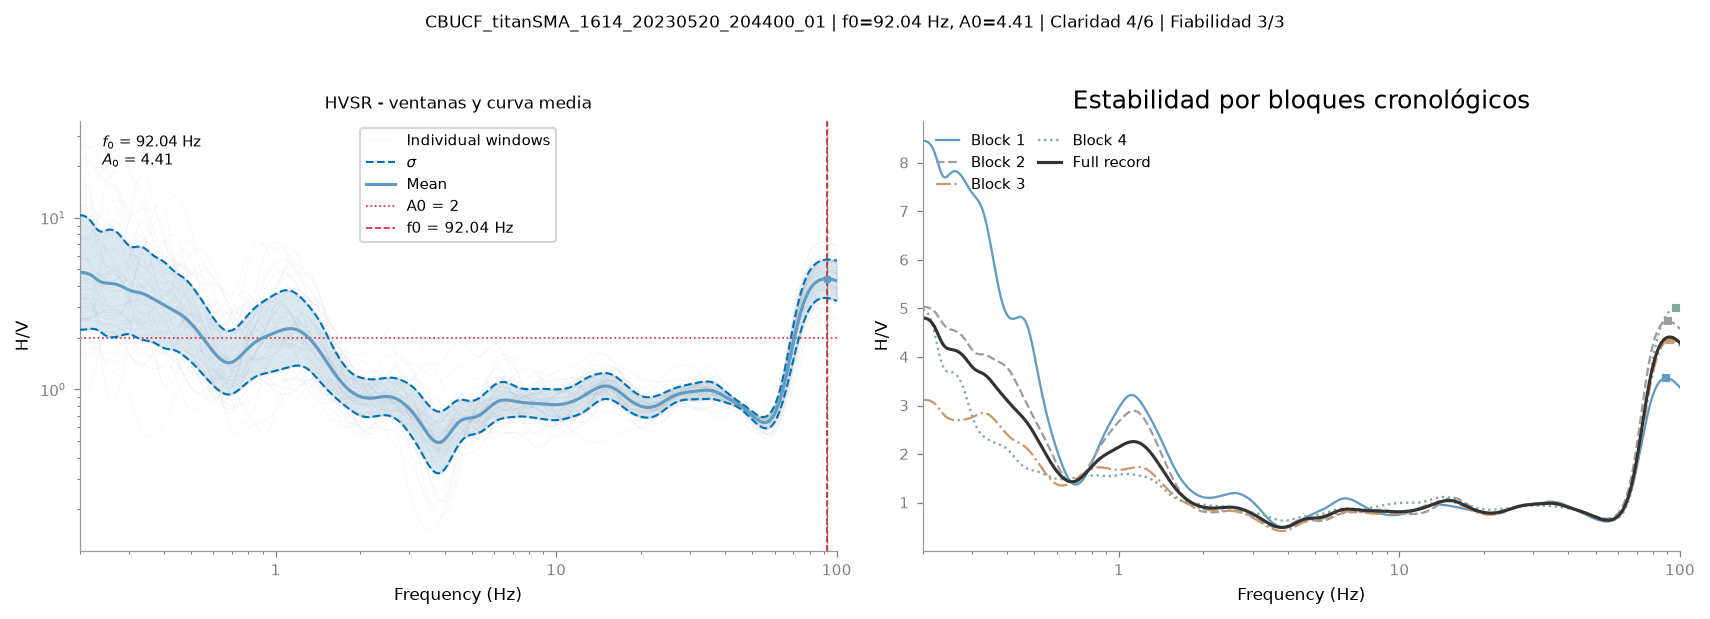

Exploratory candidate; fails: clarity 4/6; incomplete f0/4-4*f0 coverage. Site/orientation/units unverified.
Figura y diagnósticos guardados en: /home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544


{'png': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544/CBUCF_titanSMA_1614_20230520_204400_01_best_peak_analysis.png'),
 'pdf': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544/CBUCF_titanSMA_1614_20230520_204400_01_best_peak_analysis.pdf'),
 'svg': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544/CBUCF_titanSMA_1614_20230520_204400_01_best_peak_analysis.svg')}

In [3]:
style = hp.PaperStyle(width_in=11.5, font_size=8.0, tick_size=7.0, legend_size=7.0, dpi=300)
figure, axes = hp.paper_subplots(ncols=2, height_in=4.0, sharex=False, style=style)
hp.plot_hvsr(result, show_windows=True, title='HVSR - ventanas y curva media',
             ax=axes[0, 0], yscale='log', style=style)
axes[0, 0].axhline(2.0, color='tab:red', linestyle=':', linewidth=0.8, label='A0 = 2')
axes[0, 0].axvline(result.peak[0], color='tab:red', linestyle='--', linewidth=0.8,
                   label=f'f0 = {result.peak[0]:.2f} Hz')
axes[0, 0].legend(loc='best', fontsize=style.legend_size)
hp.plot_time_blocks(result, quality, ax=axes[0, 1], style=style)
axes[0, 1].set_title('Estabilidad por bloques cronológicos')
figure.suptitle(
    f"{SESSION_ID} | f0={result.peak[0]:.2f} Hz, A0={result.peak[1]:.2f} | "
    f"Claridad {quality['metrics']['clarity_count']}/6 | Fiabilidad {quality['metrics']['reliability_count']}/3",
    y=1.02, fontsize=style.font_size,
)
figure.tight_layout()
plt.show()

OUTPUT_DIR = ROOT / 'outputs/high_amplitude_sessions/2023-05-20_1544'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
figure_paths = hp.save_figure(
    figure, OUTPUT_DIR / f'{SESSION_ID}_best_peak_analysis',
    formats=('png', 'pdf', 'svg'), style=style,
)
pd.DataFrame(quality['criteria']).to_csv(OUTPUT_DIR / f'{SESSION_ID}_criteria.csv', index=False)
pd.DataFrame(quality['time_blocks']).to_csv(OUTPUT_DIR / f'{SESSION_ID}_time_blocks.csv', index=False)
m = quality['metrics']
issues = [text for failed, text in (
    (m['reliability_count'] < 3, f"reliability {m['reliability_count']}/3"),
    (m['clarity_count'] < 5, f"clarity {m['clarity_count']}/6"),
    (not m['frequency_coverage_complete'], 'incomplete f0/4-4*f0 coverage'),
    (not m['time_blocks_complete'], 'incomplete time blocks'),
    (m['block_tracked_max_deviation_pct'] > 10, f"block peak deviation {m['block_tracked_max_deviation_pct']:.1f}%"),
) if failed]
interpretation = ('Defensible candidate under the project rule' if not issues else
                  'Exploratory candidate; fails: ' + '; '.join(issues)) + '. Site/orientation/units unverified.'
print(interpretation)
summary = {
    'session_id': SESSION_ID,
    'params': params.to_dict(),
    'analysis': result.summary(),
    'quality': quality,
    'accepted_signal_coverage': coverage,
    'nyquist_hz': 0.5 / record.vt.dt_in_seconds,
    'required_upper_frequency_for_sesame_hz': 4 * result.peak[0],
    'interpretation': interpretation,
    'figure_files': {name: str(path) for name, path in figure_paths.items()},
}
(OUTPUT_DIR / f'{SESSION_ID}_summary.json').write_text(json.dumps(summary, indent=2, default=str) + '\n')
print('Figura y diagnósticos guardados en:', OUTPUT_DIR)
display(figure_paths)

## Figura de procesamiento completa

Señales de las tres componentes con ventanas aceptadas, STA/LTA, crest factor, espectros de Fourier por componente y curva HVSR con criterios SESAME. Con anti-trigger desactivado, el STA/LTA se muestra solo como diagnóstico (sin límites de rechazo).

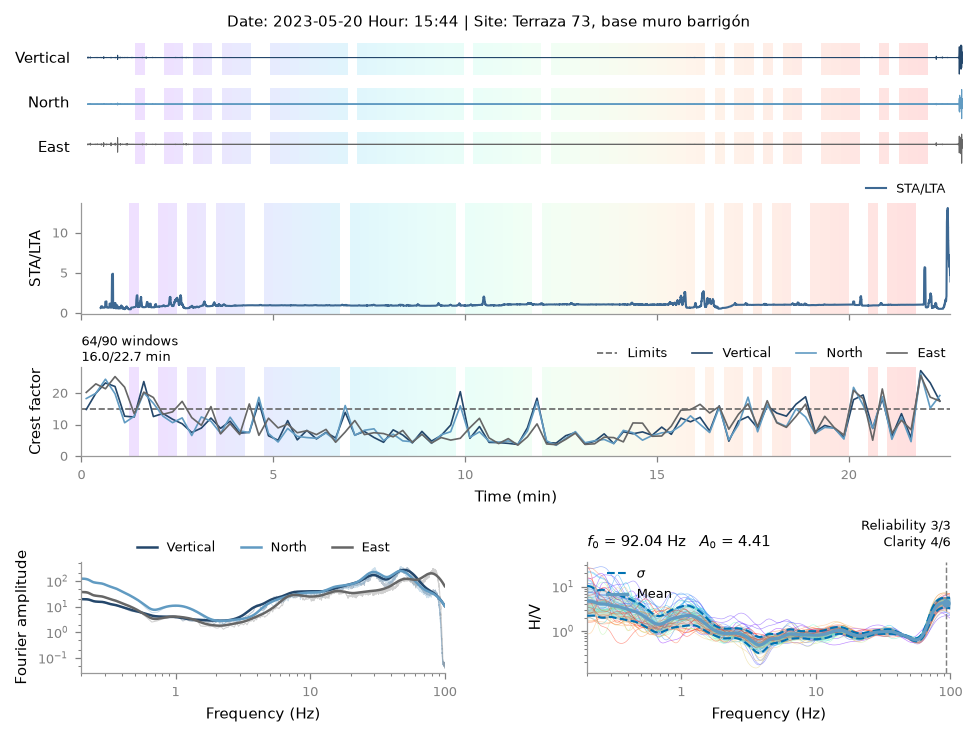

{'png': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544/CBUCF_titanSMA_1614_20230520_204400_01_analysis.png'),
 'pdf': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544/CBUCF_titanSMA_1614_20230520_204400_01_analysis.pdf'),
 'svg': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/high_amplitude_sessions/2023-05-20_1544/CBUCF_titanSMA_1614_20230520_204400_01_analysis.svg')}

In [4]:
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

FIGURE_CONTROLS = {
    'height_in': 4.8,
    'show_raw_signals': True,
    'raw_height_ratio': 1.2,
    'height_ratios': (1.0, 1.0),
    'crest_height_ratio': 0.8,
    'crest_component_alpha': 1.0,
    'component_colors': {'Z': '#24476B', 'N': '#619BC2', 'E': '#666666'},
    'component_linestyles': {'Z': '-', 'N': '-', 'E': '-'},
    'line_width': 0.8,
    'fourier_line_width': 1.2,
    'fourier_grid': False,
    'window_cmap': 'rainbow',
    'accepted_alpha': 0.12,
    'sta_lta_ylim': None,
    'sta_lta_components': ('E',),
    'sta_lta_vector_color': '#3e6993ff',
    'sta_lta_line_width': 1.0,
    'sta_lta_alpha': 1.0,
    'fourier_yscale': 'log',
    'show_unsmoothed_fourier': True,
    'unsmoothed_fourier_alpha': 0.3,
    'unsmoothed_fourier_line_width': 0.5,
    'hvsr_yscale': None,
    'hvsr_window_alpha': 0.5,
    'hvsr_title_font_size': 7.0,
    'grid': False,
    'hspace': 0.04,  # Vertical spacing between rows
    'wspace': 0.15,  # Horizontal spacing between columns
}

def make_analysis_figure(record, result, component_spectra, controls, style, show_windows=False,
                         fourier_data=None):
    if controls['show_unsmoothed_fourier'] and fourier_data is None:
        raise ValueError('Rerun the processing cell to calculate unsmoothed Fourier amplitudes.')
    labels = {'Z': 'Vertical', 'N': 'North', 'E': 'East'}
    attributes = {'Z': 'vt', 'N': 'ns', 'E': 'ew'}
    if not controls['sta_lta_components'] or not set(controls['sta_lta_components']) <= set(labels):
        raise ValueError('sta_lta_components must contain N, E and/or Z.')
    dt = record.vt.dt_in_seconds
    time = np.arange(record.vt.n_samples) * dt / 60
    with hp.paper_context(style):
        figure = plt.figure(figsize=(style.width_in, controls['height_in']), layout='constrained')
        figure.get_layout_engine().set(
            hspace=controls['hspace'],
            wspace=controls['wspace'],
        )
        show_crest = result.params.max_crest_factor is not None
        ratios = list(controls['height_ratios'])
        if show_crest:
            ratios.insert(1, controls['crest_height_ratio'])
        raw_offset = int(controls['show_raw_signals'])
        if raw_offset:
            ratios.insert(0, controls['raw_height_ratio'])
        grid = figure.add_gridspec(len(ratios), 2, height_ratios=ratios)
        sta_lta_ax = figure.add_subplot(grid[raw_offset, :])
        crest_ax = figure.add_subplot(grid[raw_offset + 1, :], sharex=sta_lta_ax) if show_crest else None
        fourier_ax = figure.add_subplot(grid[-1, 0])
        hvsr_ax = figure.add_subplot(grid[-1, 1], sharex=fourier_ax)
        raw_axes = []
        if raw_offset:
            raw_grid = grid[0, :].subgridspec(3, 1, hspace=0.02)
            for index, (component, attribute) in enumerate(attributes.items()):
                axis = figure.add_subplot(raw_grid[index, 0], sharex=sta_lta_ax)
                signal = getattr(record, attribute)
                times, lower, upper = hp.waveform_envelope(signal.amplitude, dt)
                axis.fill_between(times, lower, upper, color=controls['component_colors'][component],
                                  edgecolor=controls['component_colors'][component],
                                  linewidth=0.5, rasterized=True, zorder=1)
                axis.set_ylabel(labels[component], rotation=0, ha='right', va='center',
                                labelpad=8, fontweight='normal')
                hp.style_axes(axis, style=style)
                axis.set_yticks([])
                axis.spines['left'].set_visible(False)
                axis.spines['bottom'].set_visible(False)
                axis.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
                raw_axes.append(axis)

        starts = result.window_starts_s[result.valid_mask] / 60
        ranks = np.argsort(np.argsort(starts))
        window_colors = plt.get_cmap(controls['window_cmap'])(ranks / max(len(starts) - 1, 1))
        length = result.params.window_length_s / 60
        polygons = [[(start, 0), (start + length, 0), (start + length, 1), (start, 1)]
                    for start in starts]
        time_axes = raw_axes + [sta_lta_ax] + ([crest_ax] if show_crest else [])
        for time_axis in time_axes:
            time_axis.add_collection(PolyCollection(
                polygons, transform=time_axis.get_xaxis_transform(),
                facecolors=window_colors, alpha=controls['accepted_alpha'],
                edgecolors='none', zorder=0))
        if show_crest:
            hp.plot_crest_factor(result, ax=crest_ax, style=style,
                                 show_decisions=False,
                                 component_alpha=controls['crest_component_alpha'],
                                 component_colors=controls['component_colors'])
            crest_ax.set_title('')
            crest_ax.legend(loc='lower right', bbox_to_anchor=(1, 1.02),
                            ncols=4, borderaxespad=0, fontsize=style.legend_size)
            sta_lta_ax.tick_params(labelbottom=False)
        displayed = ('R',) if result.params.sta_lta_method == 'vector' else controls['sta_lta_components']
        for component in displayed:
            label = 'STA/LTA' if component == 'R' else labels[component]
            ratio = result.diagnostics['sta_lta'].get(component)
            if ratio is None:
                if component == 'R':
                    ratio = hv.vector_sta_lta_ratio(record, result.params.sta_s, result.params.lta_s,
                                                   result.params.sta_lta_amplitude)
                else:
                    ratio = hv.sta_lta_ratio(getattr(record, attributes[component]).amplitude, dt,
                                            result.params.sta_s, result.params.lta_s,
                                            result.params.sta_lta_amplitude)
            finite = np.flatnonzero(np.isfinite(ratio))
            if not finite.size:
                warnings.warn(f'{label} STA/LTA has no finite values.', RuntimeWarning)
                continue
            color = controls['sta_lta_vector_color'] if component == 'R' else controls['component_colors'][component]
            sta_lta_ax.plot(time, ratio, color=color,
                            linestyle='-' if component == 'R' else controls['component_linestyles'][component],
                            lw=controls['sta_lta_line_width'], alpha=controls['sta_lta_alpha'],
                            label=label, rasterized=True)
        if result.params.anti_trigger:
            for index, limit in enumerate((result.params.sta_lta_min, result.params.sta_lta_max)):
                sta_lta_ax.axhline(limit, color='0.4', ls='--', lw=0.7,
                                  label='Limits' if index == 0 else None)
        sta_lta_ax.set(xlim=(0, (record.vt.n_samples - 1) * dt / 60),
                       xlabel='Time (min)', ylabel='STA/LTA')
        if show_crest:
            sta_lta_ax.set_xlabel('')
        if controls['sta_lta_ylim'] is not None:
            sta_lta_ax.set_ylim(controls['sta_lta_ylim'])
        handles, legend_labels = sta_lta_ax.get_legend_handles_labels()
        sta_lta_ax.legend(handles, legend_labels, ncols=3, loc='lower right',
                          bbox_to_anchor=(1, 1.02), borderaxespad=0)
        included_min = hv.accepted_signal_coverage(result)['unique_duration_min']
        total_min = (record.vt.n_samples - 1) * dt / 60
        selection_annotation = (
            f'{result.n_windows}/{result.n_grid_windows} windows\n'
            f'{included_min:.1f}/{total_min:.1f} min')
        annotation_ax = crest_ax if show_crest else sta_lta_ax
        annotation_ax.text(0, 1.02, selection_annotation, transform=annotation_ax.transAxes,
                        ha='left', va='bottom', fontsize=style.legend_size)

        for component, label in labels.items():
            if controls['show_unsmoothed_fourier']:
                visible = ((fourier_data.raw_frequency >= result.params.fmin)
                           & (fourier_data.raw_frequency <= result.params.fmax))
                raw = fourier_data.raw[component][:, visible]
                log_raw = np.full_like(raw, -np.inf)
                np.log(raw, out=log_raw, where=raw > 0)
                raw_mean = np.exp(log_raw.mean(axis=0))
                fourier_ax.plot(fourier_data.raw_frequency[visible], raw_mean,
                                color=controls['component_colors'][component],
                                alpha=controls['unsmoothed_fourier_alpha'],
                                lw=controls['unsmoothed_fourier_line_width'], zorder=1,
                                label='_nolegend_', rasterized=True)
            mean = np.exp(np.log(component_spectra[component]).mean(axis=0))
            fourier_ax.plot(result.frequency, mean, label=label,
                            color=controls['component_colors'][component],
                            linestyle=controls['component_linestyles'][component],
                            lw=controls['fourier_line_width'], zorder=2)
        fourier_ax.set(xscale='log', yscale=controls['fourier_yscale'],
                       xlim=(result.params.fmin, result.params.fmax), xlabel='Frequency (Hz)',
                       ylabel='Fourier amplitude')
        fourier_ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
        fourier_ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
                          ncols=3, borderaxespad=0)
        hp.plot_hvsr(result, show_windows=show_windows, title='', ax=hvsr_ax,
                     yscale=controls['hvsr_yscale'],
                     window_alpha=controls['hvsr_window_alpha'],
                     window_cmap=controls['window_cmap'], style=style)
        peak_annotation = hvsr_ax.texts[0]
        peak_title = peak_annotation.get_text().replace('\n', '   ')
        peak_annotation.remove()
        hvsr_ax.set_title(peak_title, loc='center', y=1.1, pad=0,
                          fontweight='normal', math_fontfamily='dejavusans')
        hvsr_ax.title.set_x(0)
        hvsr_ax.title.set_horizontalalignment('left')
        hvsr_ax.title.set_verticalalignment('bottom')
        legend_handles, legend_labels = hvsr_ax.get_legend_handles_labels()
        legend_order = [legend_labels.index(label) for label in (r'$\sigma$', 'Mean')
                        if label in legend_labels]
        hvsr_ax.legend([legend_handles[index] for index in legend_order],
                       [legend_labels[index] for index in legend_order],
                       loc='upper left', bbox_to_anchor=(0.04, 1),
                       ncols=1, borderaxespad=0, fontsize=style.legend_size, frameon=False)
        sesame_metrics = hv.assess_sesame_quality(result, time_blocks=None)['metrics']
        sesame_label = (
            f"Reliability {sesame_metrics['reliability_count']}/3\n"
            f"Clarity {sesame_metrics['clarity_count']}/6")
        hvsr_ax.text(1, 1.1, sesame_label, transform=hvsr_ax.transAxes,
                     ha='right', va='bottom', fontsize=style.legend_size,
                     fontweight='normal')
        for axis in (sta_lta_ax, fourier_ax, hvsr_ax):
            hp.style_axes(axis, grid=controls['grid'], style=style)
        if controls['fourier_yscale'] == 'log':
            fourier_ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1,)))
            fourier_ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 5)))
            fourier_ax.yaxis.set_minor_formatter(NullFormatter())
        if controls['fourier_grid']:
            fourier_ax.grid(which='major', color='0.92', linewidth=0.4)
        hvsr_ax.title.set_fontsize(controls['hvsr_title_font_size'])
        return figure

ANALYSIS_STYLE = hp.PaperStyle(width_in=6.4, font_size=7.0, tick_size=6.0, legend_size=6.0, dpi=300)
fourier_data = hv.component_fourier_data(record, result)
component_spectra = fourier_data.smoothed
analysis_figure = make_analysis_figure(record, result, component_spectra, FIGURE_CONTROLS,
                                       ANALYSIS_STYLE, show_windows=True,
                                       fourier_data=fourier_data)
start_colombia = pd.Timestamp(session['starttime']).tz_convert('America/Bogota')
analysis_figure.suptitle(
    f"Date: {start_colombia:%Y-%m-%d} Hour: {start_colombia:%H:%M} | Site: Terraza 73, base muro barrigón",
    fontsize=ANALYSIS_STYLE.font_size,
)
plt.show()
analysis_paths = hp.save_figure(
    analysis_figure, OUTPUT_DIR / f'{SESSION_ID}_analysis',
    formats=('png', 'pdf', 'svg'), style=ANALYSIS_STYLE,
)
summary['figure_files'].update({f'analysis_{name}': str(path) for name, path in analysis_paths.items()})
(OUTPUT_DIR / f'{SESSION_ID}_summary.json').write_text(json.dumps(summary, indent=2, default=str) + '\n')
display(analysis_paths)
